1. Đọc data và xem tổng quan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)



2. Load data

In [2]:
DATA_PATH = "../data/raw/paysim.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


3. Dataset overview

Xem schema

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Thống kê cơ bản

In [4]:
df.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Missing values

In [5]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)


Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


4. Target analysis 

In [6]:
fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)


isFraud
0    6354407
1       8213
Name: count, dtype: int64


Visualization 

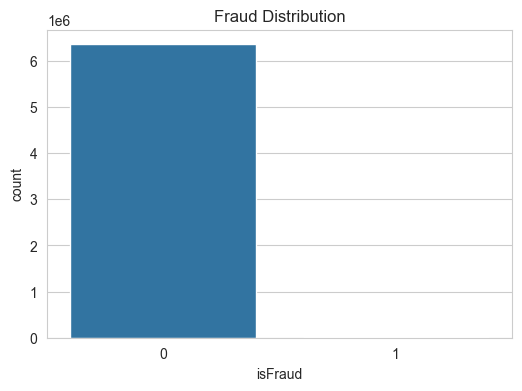

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud Distribution")
plt.show()


Tỷ lệ fraud

In [8]:
fraud_ratio = df["isFraud"].mean()

print(f"Fraud ratio: {fraud_ratio:.6f}")


Fraud ratio: 0.001291


5. Transaction type analysis

Distribution của transaction type

In [9]:
print(df["type"].value_counts())


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


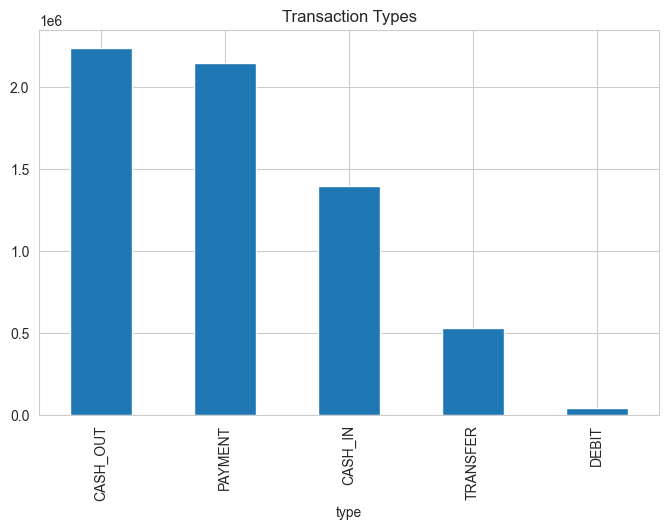

In [10]:
plt.figure(figsize=(8,5))

df["type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Types")
plt.show()


Fraud xuất hiện ở loại nào?

In [11]:
type_fraud = pd.crosstab(
    df["type"],
    df["isFraud"]
)

print(type_fraud)


isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


Fraud rate theo type

In [12]:
type_fraud_rate = pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
)

print(type_fraud_rate)


isFraud          0         1
type                        
CASH_IN   1.000000  0.000000
CASH_OUT  0.998160  0.001840
DEBIT     1.000000  0.000000
PAYMENT   1.000000  0.000000
TRANSFER  0.992312  0.007688


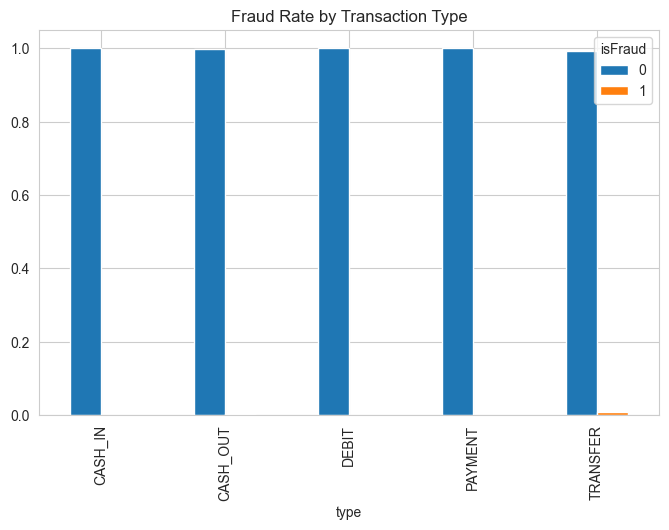

In [13]:
type_fraud_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Transaction Type")
plt.show()


6. Amount analysis

Raw distribution

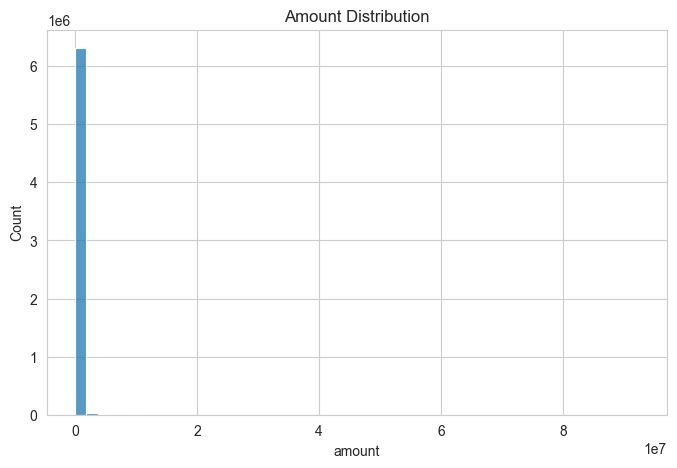

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["amount"],
    bins=50
)

plt.title("Amount Distribution")
plt.show()


Log distribution

In [15]:
df["log_amount"] = np.log1p(df["amount"])


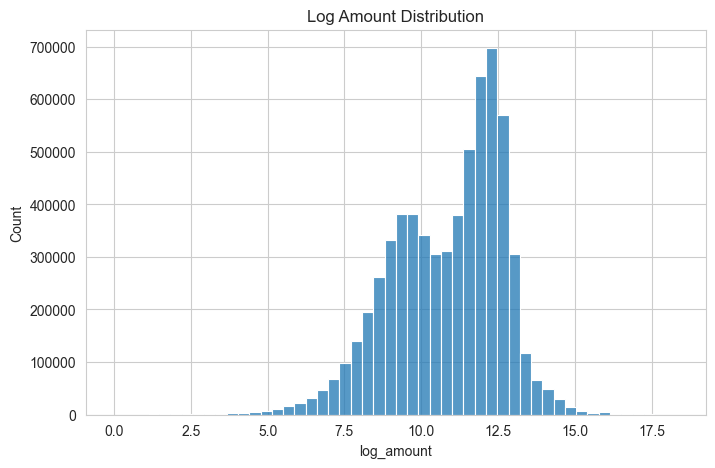

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["log_amount"],
    bins=50
)

plt.title("Log Amount Distribution")
plt.show()


Fraud vs non-fraud

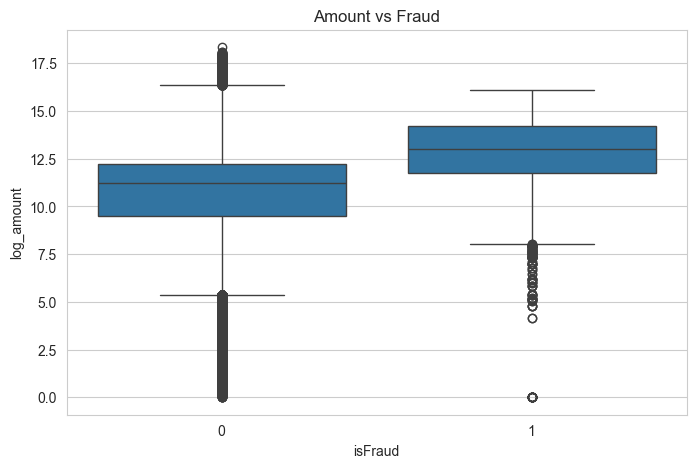

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="log_amount"
)

plt.title("Amount vs Fraud")
plt.show()


7. Balance analysis

In [18]:
df["orig_balance_diff"] = (
    df["oldbalanceOrg"]
    - df["newbalanceOrig"]
)

df["dest_balance_diff"] = (
    df["newbalanceDest"]
    - df["oldbalanceDest"]
)


Sender behavior

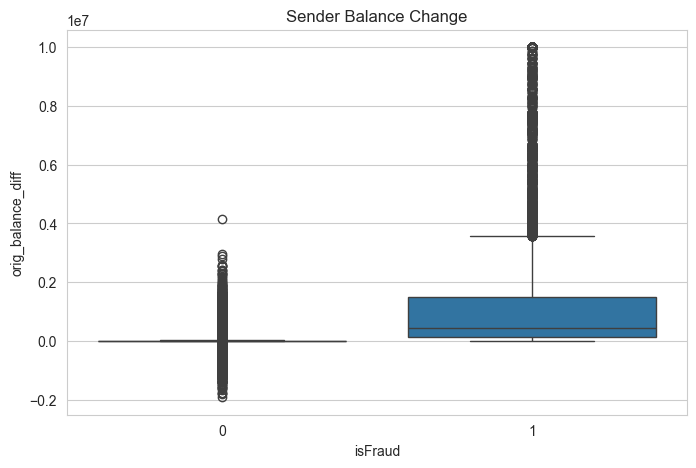

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="orig_balance_diff"
)

plt.title("Sender Balance Change")
plt.show()


Receiver behavior

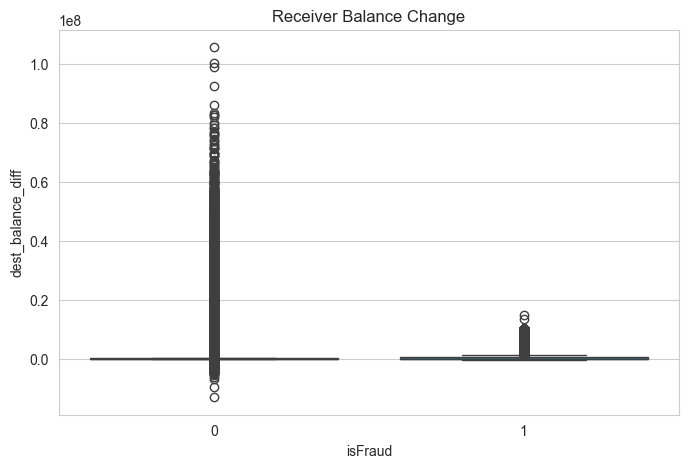

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="dest_balance_diff"
)

plt.title("Receiver Balance Change")
plt.show()


8. Time analysis

Volume theo thời gian

In [21]:
hourly_tx = df.groupby("step").size()


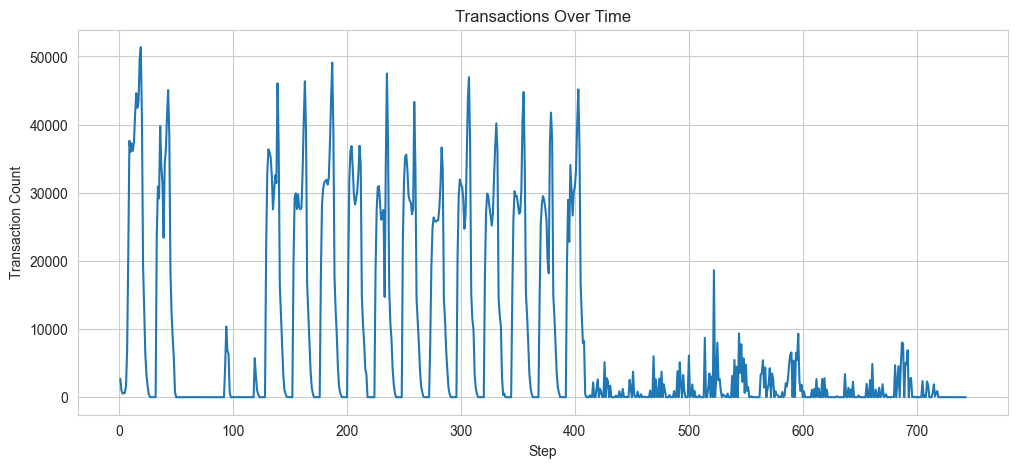

In [22]:
plt.figure(figsize=(12,5))

hourly_tx.plot()

plt.title("Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Transaction Count")
plt.show()


Fraud theo thời gian

In [23]:
hourly_fraud = df.groupby("step")["isFraud"].sum()


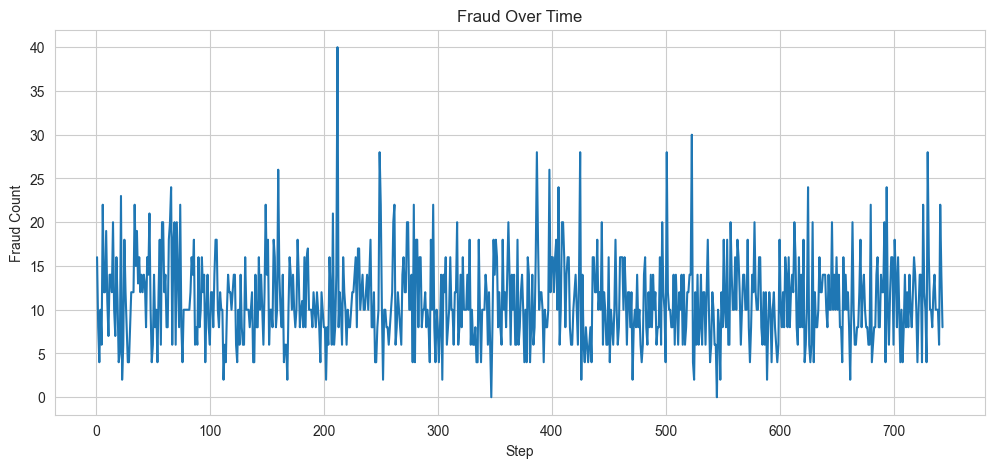

In [24]:
plt.figure(figsize=(12,5))

hourly_fraud.plot()

plt.title("Fraud Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.show()


9. Correlation analysis

In [25]:
numeric_cols = df.select_dtypes(
    include=np.number
)


In [26]:
corr = numeric_cols.corr()


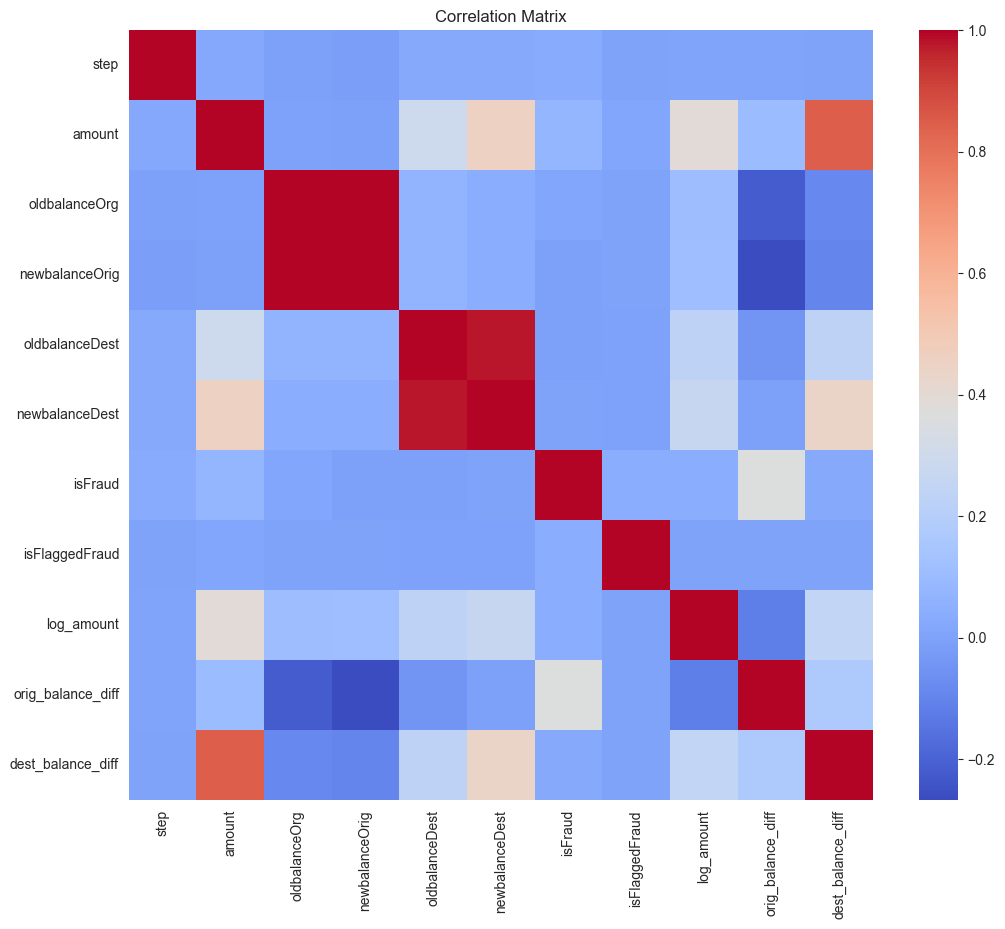

In [27]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()


10. Graph-oriented EDA

Sender degree

In [28]:
sender_degree = df["nameOrig"].value_counts()

print(sender_degree.describe())


count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64


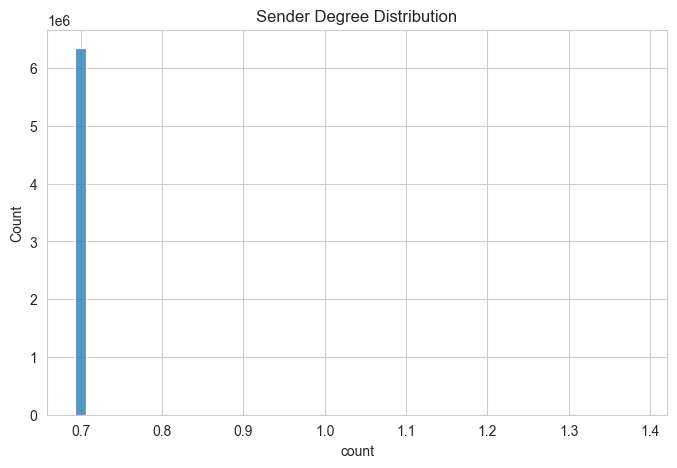

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(sender_degree),
    bins=50
)

plt.title("Sender Degree Distribution")
plt.show()


Receiver degree

In [30]:
receiver_degree = df["nameDest"].value_counts()

print(receiver_degree.describe())


count    2.722362e+06
mean     2.337169e+00
std      4.549264e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.130000e+02
Name: count, dtype: float64


Fraud accounts

In [31]:
fraud_df = df[
    df["isFraud"] == 1
]


Sender fraud frequency

In [32]:
fraud_senders = fraud_df[
    "nameOrig"
].value_counts()

print(fraud_senders.head(20))


nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
C1635772897    1
C669700766     1
C1275464847    1
C13692003      1
C1872047468    1
C1499825229    1
C1093223281    1
C77163673      1
C1440057381    1
C430329518     1
Name: count, dtype: int64


Receiver fraud frequency

In [33]:
fraud_receivers = fraud_df[
    "nameDest"
].value_counts()

print(fraud_receivers.head(20))


nameDest
C967226405     2
C1601170327    2
C650699445     2
C105660024     2
C1981613973    2
C803116137     2
C505532836     2
C964377943     2
C200064275     2
C1259079602    2
C1650668671    2
C385133759     2
C1656842502    2
C1185292292    2
C904300960     2
C2020337583    2
C1460854172    2
C1366192319    2
C2129197098    2
C644163395     2
Name: count, dtype: int64


11. Generate summary insights

In [34]:
print("="*50)

print("EDA SUMMARY")

print("="*50)

print(
    f"Total transactions: {len(df):,}"
)

print(
    f"Fraud ratio: {fraud_ratio:.6f}"
)

print(
    f"Unique senders: {df['nameOrig'].nunique():,}"
)

print(
    f"Unique receivers: {df['nameDest'].nunique():,}"
)

print(
    f"Transaction types: {df['type'].unique()}"
)


EDA SUMMARY
Total transactions: 6,362,620
Fraud ratio: 0.001291
Unique senders: 6,353,307
Unique receivers: 2,722,362
Transaction types: ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
